In [1]:
import numpy as np
import pandas as pd

In [2]:
import addtl_bt_fns

In [3]:
btresults_path = '../backtesting_results/run_20260121_123432/'

# Load all data files
daily_pf = pd.read_csv(btresults_path + 'daily_portfolio_values.csv')
comparison_df = pd.read_csv(btresults_path + 'portfolio_vs_index.csv')
trade_results = pd.read_csv(btresults_path + 'trade_results.csv')

print(f"Daily Portfolio Values: {daily_pf.shape}")
print(f"Portfolio vs Index: {comparison_df.shape}")
print(f"Trade Results: {trade_results.shape}")


Daily Portfolio Values: (2577, 3)
Portfolio vs Index: (2577, 6)
Trade Results: (900, 15)


## 1. Daily Portfolio Value Analysis

In [4]:
# Compute comprehensive portfolio metrics
portfolio_metrics = addtl_bt_fns.compute_portfolio_metrics(daily_pf, risk_free_rate=0.065)
print("=== Portfolio Metrics ===")
for key, value in portfolio_metrics.items():
    print(f"{key}: {value}")

=== Portfolio Metrics ===
start_date: 2014-06-02
end_date: 2025-08-14
trading_days: 2577
years: 11.2
initial_value: 1000000000.0
final_value: 1592045484.7264187
total_return_pct: 59.2
cagr_pct: 4.24
volatility_pct: 12.0
sharpe_ratio: -0.188
sortino_ratio: -0.248
max_drawdown_pct: -27.36
calmar_ratio: 0.155
var_95_pct: -1.07
best_day_pct: 5.17
worst_day_pct: -10.85
positive_days_pct: 48.72


In [5]:
# Compute drawdown series
drawdown_series = addtl_bt_fns.compute_drawdown_series(daily_pf)
print("=== Drawdown Series (first 10 rows) ===")
drawdown_series.head(10)

=== Drawdown Series (first 10 rows) ===


,date,portfolio_value,cummax,drawdown,drawdown_pct
0,2014-06-02,1.000000e+09,1.000000e+09,0.000000e+00,0.000000
1,2014-06-03,1.000000e+09,1.000000e+09,0.000000e+00,0.000000
2,2014-06-04,1.000000e+09,1.000000e+09,0.000000e+00,0.000000
3,2014-06-05,1.027280e+09,1.027280e+09,0.000000e+00,0.000000
4,2014-06-06,1.052294e+09,1.052294e+09,0.000000e+00,0.000000
5,2014-06-09,1.093959e+09,1.093959e+09,0.000000e+00,0.000000
6,2014-06-10,1.069951e+09,1.093959e+09,-2.400875e+07,-2.194666
7,2014-06-11,1.056750e+09,1.093959e+09,-3.720971e+07,-3.401380
8,2014-06-12,1.053631e+09,1.093959e+09,-4.032838e+07,-3.686461
9,2014-06-13,1.038951e+09,1.093959e+09,-5.500825e+07,-5.028363


In [6]:
# Compute rolling returns (trading day based: 21d=1M, 63d=3M, 126d=6M, 252d=1Y)
rolling_returns = addtl_bt_fns.compute_rolling_returns(daily_pf, windows=[21, 63, 126, 252])
print("=== Rolling Returns (last 10 rows) ===")
rolling_returns.tail(10)

=== Rolling Returns (last 10 rows) ===


,date,portfolio_value,return_1M,return_3M,return_6M,return_1Y
2567,2025-08-01,1.592662e+09,-1.197493,-1.899065,-3.819690,-4.296805
2568,2025-08-04,1.597162e+09,-1.056164,-1.711257,-3.604200,-4.132251
2569,2025-08-05,1.595136e+09,-0.790465,-1.604529,-3.718284,-4.374075
2570,2025-08-06,1.594991e+09,-0.960416,-1.591845,-3.682540,-4.609758
2571,2025-08-07,1.601815e+09,-0.758783,-1.173860,-3.200428,-4.156132
2572,2025-08-08,1.596465e+09,-0.790063,-1.522554,-3.323804,-4.476287
2573,2025-08-11,1.595703e+09,-0.331763,-1.516263,-3.408784,-4.521853
2574,2025-08-12,1.596055e+09,0.040069,-1.565864,-3.387505,-4.500819
2575,2025-08-13,1.595674e+09,-0.235780,-1.717463,-3.410569,-4.533380
2576,2025-08-14,1.592045e+09,-0.420254,-2.018275,-3.630193,-4.270094


In [7]:
# Compute calendar-based rolling returns (1M, 3M, 6M, 12M calendar months)
calendar_rolling_returns = addtl_bt_fns.compute_calendar_rolling_returns(daily_pf, periods=[1, 3, 6, 12])
print("=== Calendar Rolling Returns (last 10 rows) ===")
calendar_rolling_returns.tail(10)

=== Calendar Rolling Returns (last 10 rows) ===


,date,portfolio_value,return_1M_cal,return_3M_cal,return_6M_cal,return_1Y_cal
2567,2025-08-01,1.592662e+09,-1.374344,-2.271435,-4.016341,-4.703813
2568,2025-08-04,1.597162e+09,-1.056164,-1.975094,-3.547941,-4.434562
2569,2025-08-05,1.595136e+09,-1.181670,-2.138653,-3.726474,-4.555783
2570,2025-08-06,1.594991e+09,-1.190637,-1.755593,-3.727021,-4.564443
2571,2025-08-07,1.601815e+09,-0.375048,-1.424893,-3.270456,-4.156132
2572,2025-08-08,1.596465e+09,-0.868931,-1.522575,-3.593569,-4.476287
2573,2025-08-11,1.595703e+09,-0.331763,-1.547929,-3.369920,-4.521853
2574,2025-08-12,1.596055e+09,-0.309806,-1.529272,-3.387505,-4.500819
2575,2025-08-13,1.595674e+09,-0.333605,-1.571348,-3.410569,-4.523618
2576,2025-08-14,1.592045e+09,-0.211229,-1.742010,-3.630193,-4.740710


In [8]:
# Compute monthly returns table (Year x Month pivot)
monthly_returns = addtl_bt_fns.compute_monthly_returns(daily_pf)
print("=== Monthly Returns Table ===")
monthly_returns

=== Monthly Returns Table ===


c:\Users\shaanilpunglia\Documents\qpf\src\addtl_bt_fns.py:223: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly.pct_change() * 100


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2014,NaN,NaN,NaN,NaN,NaN,NaN,-0.36,-1.69,1.02,0.10,-1.10,-0.47,4.57
2015,0.71,1.40,-0.52,1.45,0.22,0.51,0.88,-12.95,-2.81,-0.46,5.17,1.62,-5.75
2016,-2.09,-3.52,11.22,1.48,0.11,3.63,0.30,3.24,0.54,2.23,5.18,-0.83,22.78
2017,5.05,3.71,0.72,1.69,-0.88,3.48,2.55,1.17,1.64,2.88,4.07,1.44,31.09
2018,1.80,0.46,-3.26,2.33,-1.15,-2.51,0.46,4.79,-7.32,-0.56,-2.46,-0.95,-8.54
2019,-0.19,4.60,5.03,-4.58,-0.39,-7.68,-6.46,-4.47,-1.54,1.63,6.23,-1.66,-10.12
2020,0.69,-3.56,-3.93,0.00,0.00,8.27,0.92,2.35,0.69,0.56,3.21,2.99,12.30
2021,0.08,1.50,-2.48,2.23,0.24,3.06,1.53,-5.84,3.50,0.97,-6.00,5.85,3.99
2022,2.24,-7.86,0.94,3.27,-2.18,-9.15,3.31,-0.15,2.81,0.10,2.72,-0.68,-5.47


## 2. Benchmark Comparison Analysis

In [9]:
# Compute benchmark comparison metrics (beta, tracking error, information ratio, etc.)
benchmark_metrics = addtl_bt_fns.compute_benchmark_metrics(comparison_df)
print("=== Benchmark Comparison Metrics ===")
for key, value in benchmark_metrics.items():
    print(f"{key}: {value}")

=== Benchmark Comparison Metrics ===
portfolio_return_pct: 59.2
index_return_pct: 335.38
alpha_pct: -276.17
beta: 0.401
tracking_error_pct: 13.75
information_ratio: -0.746
up_capture_pct: 45.58
down_capture_pct: 47.89
correlation: 0.503
outperformance_days_pct: 44.57


In [10]:
# Compute rolling alpha (63 trading days = ~3 months)
rolling_alpha = addtl_bt_fns.compute_rolling_alpha(comparison_df, window=63)
print("=== Rolling Alpha (trading day based, last 10 rows) ===")
rolling_alpha.tail(10)

=== Rolling Alpha (trading day based, last 10 rows) ===


,date,rolling_alpha
2567,2025-08-01,-5.685048
2568,2025-08-04,-5.809033
2569,2025-08-05,-6.513493
2570,2025-08-06,-6.705611
2571,2025-08-07,-2.510326
2572,2025-08-08,-2.470315
2573,2025-08-11,-2.640805
2574,2025-08-12,-1.163627
2575,2025-08-13,-1.498765
2576,2025-08-14,-1.772944


In [11]:
# Compute rolling alpha based on calendar months
rolling_alpha_calendar = addtl_bt_fns.compute_rolling_alpha_calendar(comparison_df, period=3)
print("=== Rolling Alpha (calendar month based, 3M, last 10 rows) ===")
rolling_alpha_calendar.tail(10)

=== Rolling Alpha (calendar month based, 3M, last 10 rows) ===


,date,pf_rolling_return,index_rolling_return,rolling_alpha
2502,2025-08-01,-2.271435,3.440943,-5.712378
2503,2025-08-04,-1.975094,4.413102,-6.388196
2504,2025-08-05,-2.138653,3.245660,-5.384313
2505,2025-08-06,-1.755593,3.772322,-5.527915
2506,2025-08-07,-1.424893,3.354739,-4.779632
2507,2025-08-08,-1.522575,3.292195,-4.814770
2508,2025-08-11,-1.547929,4.971688,-6.519617
2509,2025-08-12,-1.529272,0.828780,-2.358052
2510,2025-08-13,-1.571348,2.145650,-3.716998
2511,2025-08-14,-1.742010,1.412708,-3.154718


## 3. Plotting Functions

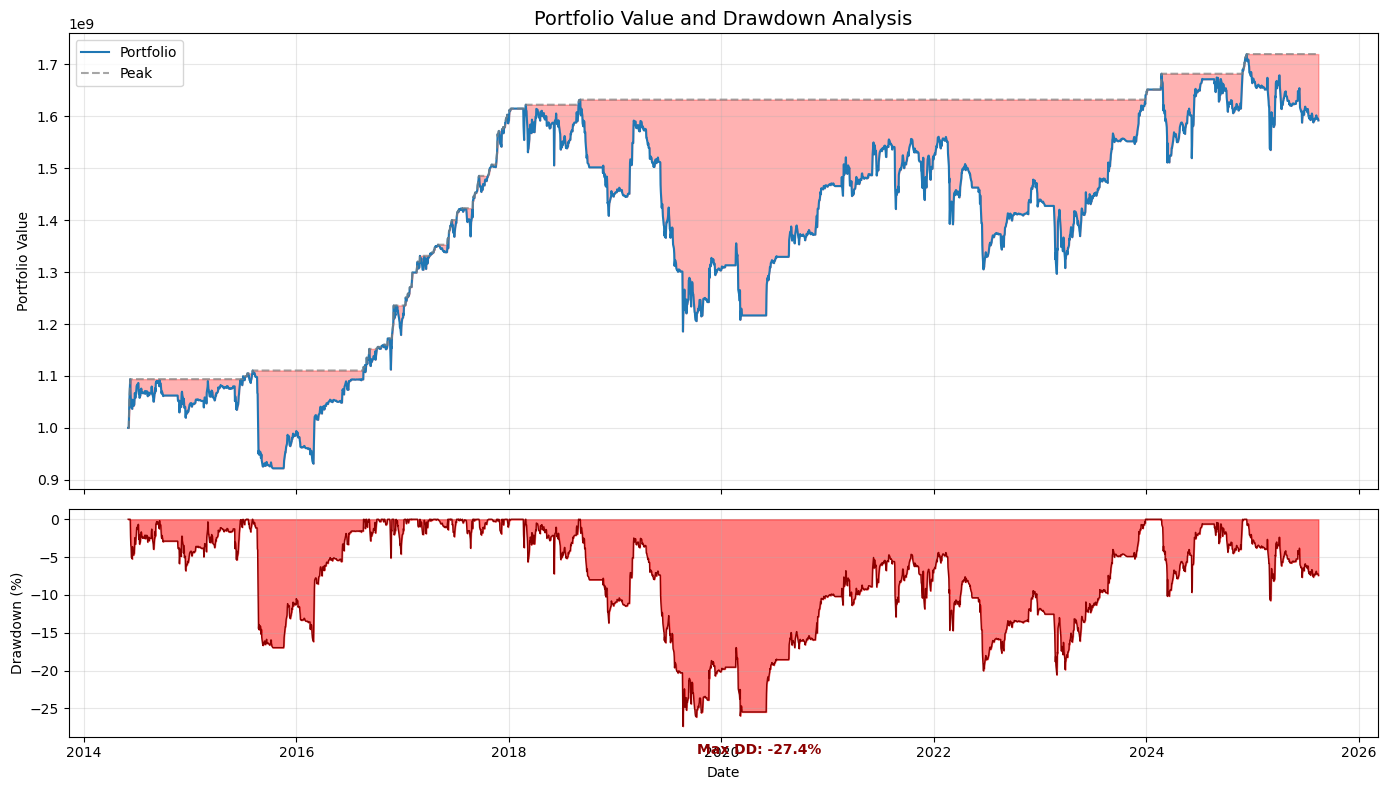

In [12]:
# Plot drawdown chart
addtl_bt_fns.plot_drawdown(daily_pf)

c:\Users\shaanilpunglia\Documents\qpf\src\addtl_bt_fns.py:223: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly.pct_change() * 100


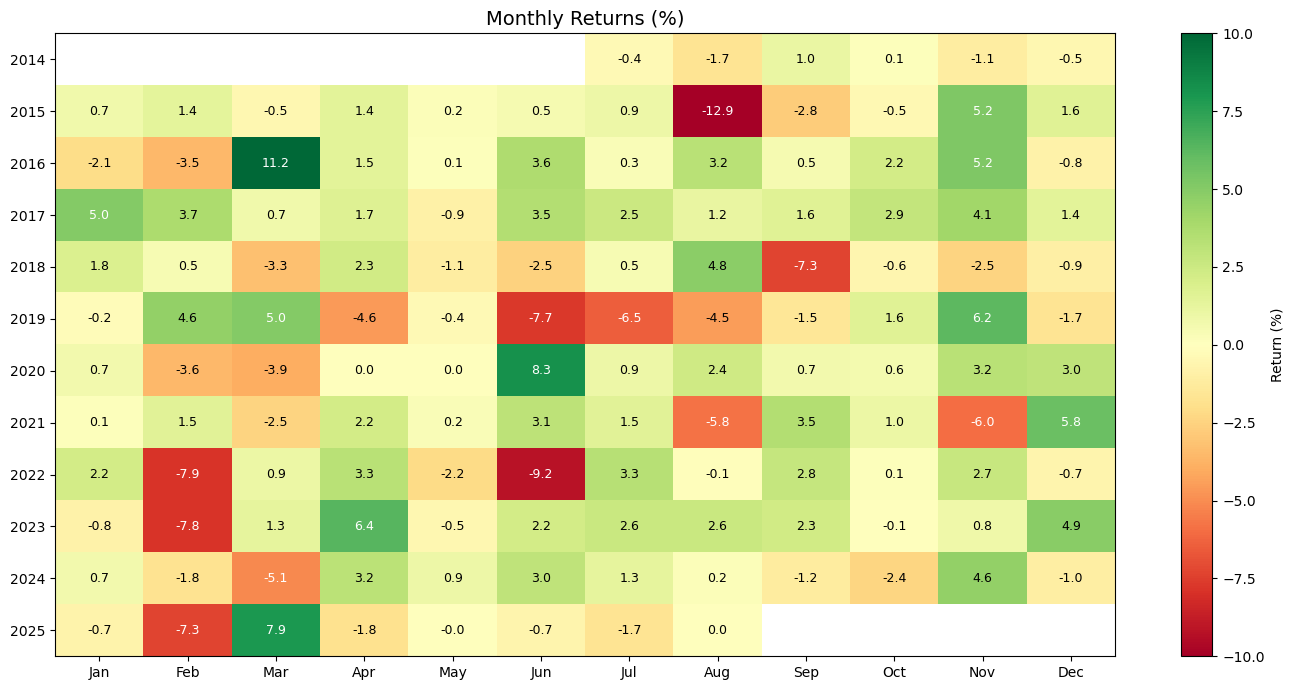

In [13]:
# Plot monthly returns heatmap
addtl_bt_fns.plot_monthly_returns_heatmap(daily_pf)

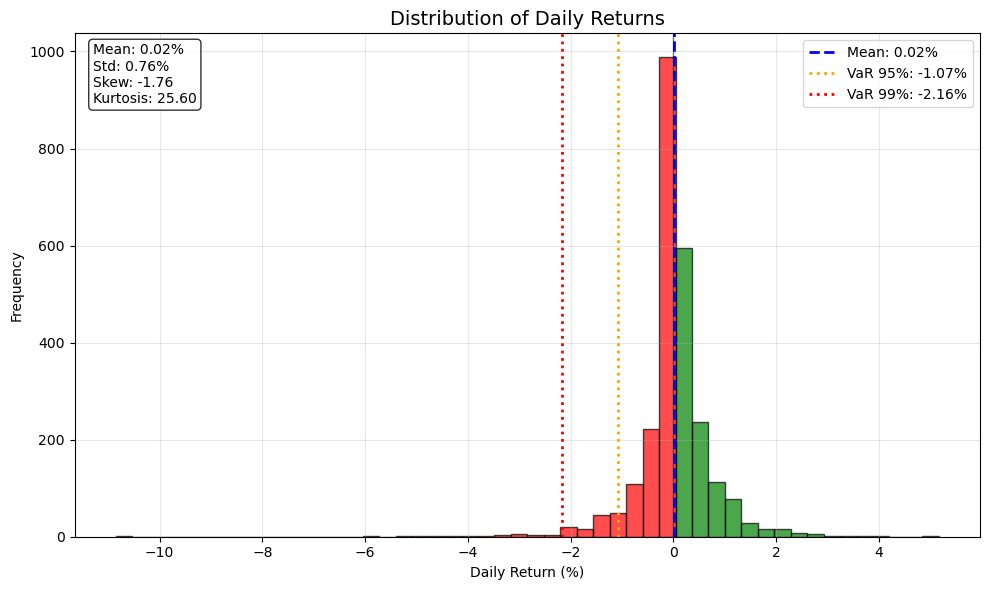

In [14]:
# Plot daily returns distribution histogram
addtl_bt_fns.plot_return_distribution(daily_pf)

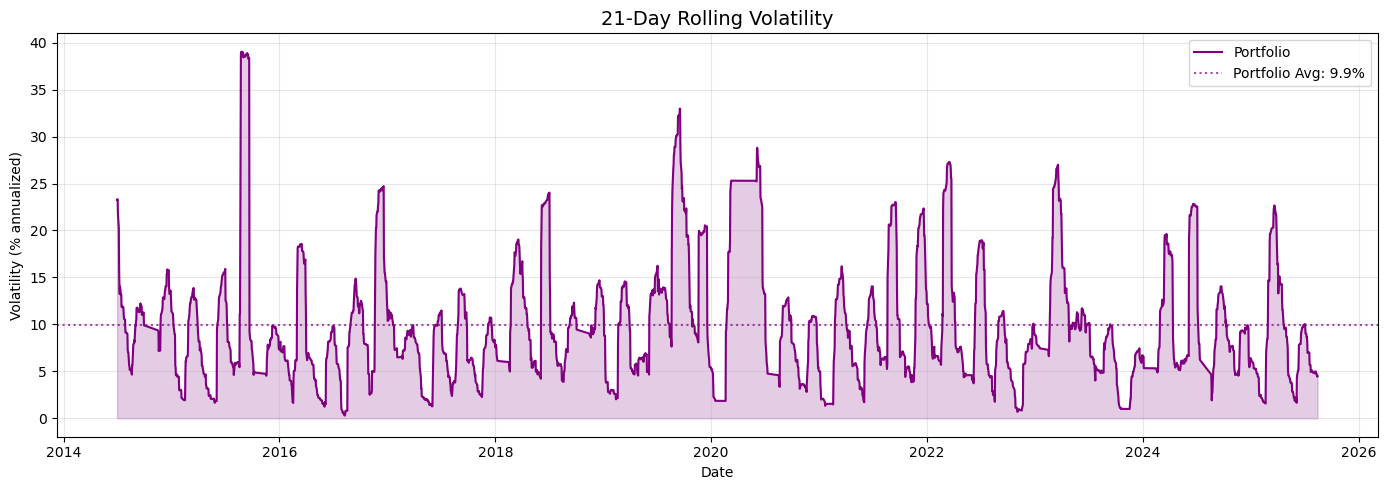

In [15]:
# Plot rolling volatility (21-day window)
addtl_bt_fns.plot_rolling_volatility(daily_pf, window=21)

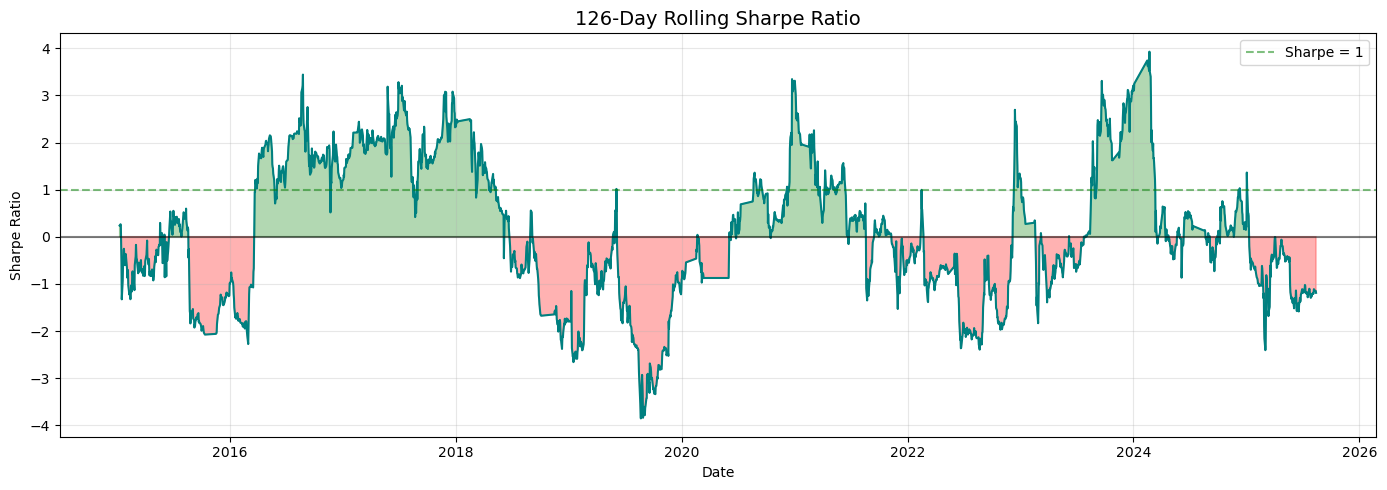

In [16]:
# Plot rolling Sharpe ratio (126-day = 6 month window)
addtl_bt_fns.plot_rolling_sharpe(daily_pf, window=126, risk_free_rate=0.065)

In [17]:
# Generate full analysis report (combines metrics + plots)
# Set output_dir to save plots, or None to display inline
report = addtl_bt_fns.generate_full_analysis_report(
    daily_pf, 
    comparison_df=comparison_df, 
    output_dir=None  # Change to a path to save plots
)
print("Report keys:", list(report.keys()))

Report keys: ['portfolio_metrics', 'monthly_returns', 'rolling_returns', 'drawdown_series', 'benchmark_metrics', 'rolling_alpha']


c:\Users\shaanilpunglia\Documents\qpf\src\addtl_bt_fns.py:223: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly.pct_change() * 100


## 4. Category-Level Plotting Functions

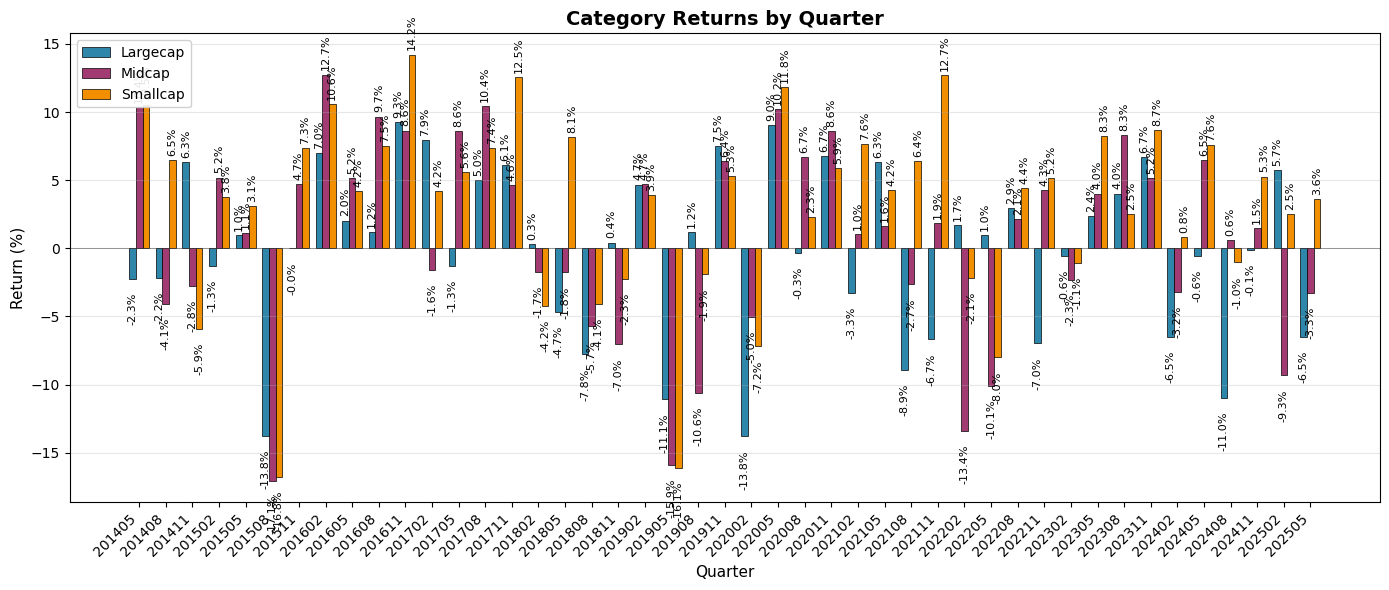

In [18]:
# Plot category returns by quarter (grouped bar chart)
addtl_bt_fns.plot_category_returns_by_quarter(trade_results)

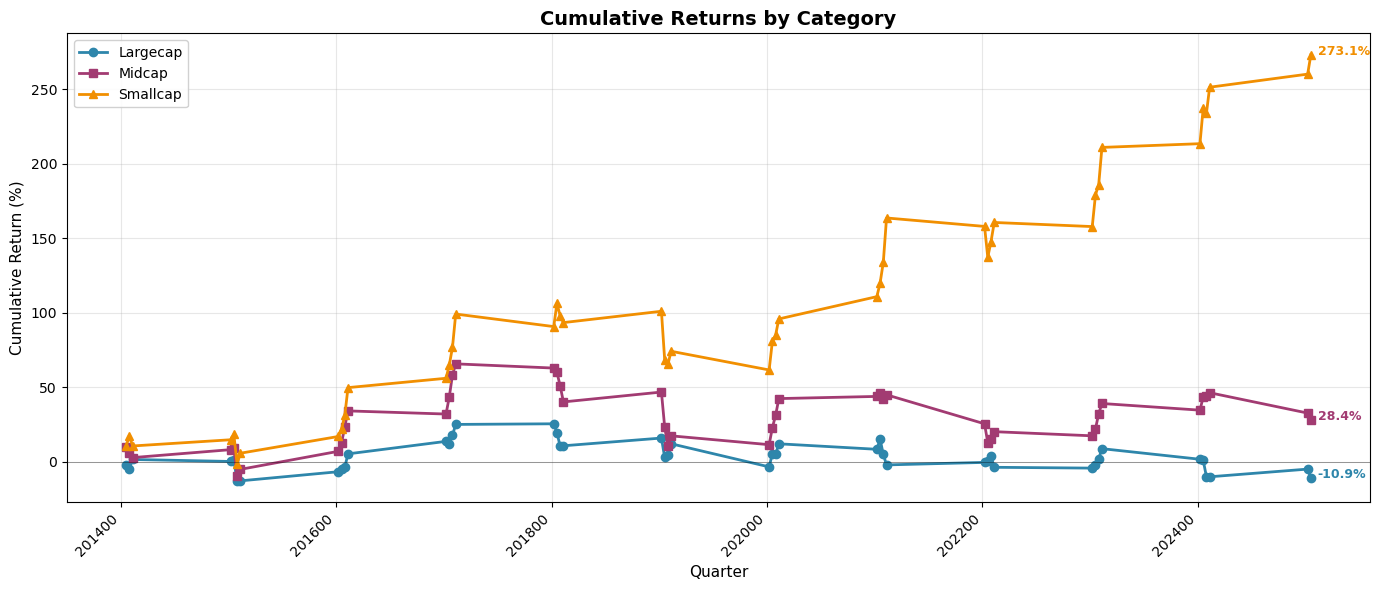

In [19]:
# Plot cumulative returns by category (line chart)
addtl_bt_fns.plot_category_cumulative_returns(trade_results)

In [22]:
# Generate category analysis report (combines metrics + plots)
category_report = addtl_bt_fns.generate_category_analysis_report(
    trade_results, 
    output_dir=None  # Change to a path to save plots
)
print("Category Report keys:", list(category_report.keys()))

Category Report keys: ['stock_counts', 'category_returns', 'holding_periods', 'quarter_analysis']


## 5. Trade-Level Analysis Functions

In [28]:
# Get comprehensive quarter analysis (combines counts, returns, holding periods, TP/SL stats)
quarter_analysis = addtl_bt_fns.get_comprehensive_quarter_analysis(trade_results)
print("=== Comprehensive Quarter Analysis ===")
quarter_analysis

=== Comprehensive Quarter Analysis ===


,quarter,total_stocks,smallcap_count,largecap_count,midcap_count,avg_holding_period,TP_count,SL_count,time_exit_count,avg_holding_period_SL,avg_holding_period_TP,largecap_avg_hp,largecap_return,midcap_avg_hp,midcap_return,smallcap_avg_hp,smallcap_return,portfolio_return
0,201405,20,8,6,6,27.80,14,1,5,6.00,13.57,50.50,-0.022587,20.17,0.103802,16.50,0.105477,0.066388
1,201408,19,7,6,6,15.42,12,7,0,22.71,11.17,16.17,-0.021524,22.17,-0.041016,9.00,0.064876,-0.003401
2,201411,20,8,6,6,28.30,11,8,1,26.38,24.36,21.83,0.063271,31.50,-0.027522,30.75,-0.059216,-0.009793
3,201502,19,7,6,6,28.74,12,6,1,31.67,21.33,25.83,-0.013032,34.50,0.051858,26.29,0.037602,0.028114
4,201505,20,8,6,6,26.15,13,5,2,20.60,21.08,32.50,0.009543,20.83,0.010916,25.38,0.031119,0.016565
5,201508,20,8,6,6,14.85,1,19,0,13.05,49.00,6.00,-0.137820,20.33,-0.170673,17.38,-0.167599,-0.159895
6,201511,20,8,6,6,28.10,15,4,1,63.00,14.87,42.33,-0.000036,21.00,0.047123,22.75,0.073491,0.040886
7,201602,18,6,6,6,32.28,15,2,1,17.00,29.53,37.00,0.070120,32.17,0.127415,27.67,0.106106,0.103834
8,201605,20,8,6,6,21.15,15,4,1,20.25,18.00,19.67,0.020291,17.83,0.051613,24.75,0.042078,0.039356
9,201608,20,8,6,6,27.25,17,3,0,28.67,27.00,37.17,0.011987,24.33,0.096603,22.00,0.075250,0.064812
